# 3.41 Calibration -- VIS and NIR Earthshine

OVERVIEW: Observe moderately bright point sources that are near Earth's keep-out angle to assess background flux due to the Earth. The sources should be chosen such that the location of the Earth relative to the spacecraft coordinate system is varied to determine if there is an orientation dependence on Earth-induced background flux.


DATA PRODUCT: 
- RD-C2: This data will be used to develop a model of the Earthshine background. 
   
   
EXIT CRITERIA: observations obtained, analysis complete and summarized in 3.41_ResultsSummary.md
- Data with TBD S/N of # point sources taken with the Earth near the keep-out angle.


DATA VOLUME: 30 observations in two parts, 15 observations each. All observation are simultaneous NIR and VIS. 
- in part 1: full 2048x2048 VIS FOV, NIR subarray 516x2084
- in part 2: 9 100x100 VIS subarrays, NIR subarray 84x400

Note: to reduce data volume and for the prioritization of other tasks, this task may be reduced to fewer targets/observations
    

TARGET CRITERIA: A primary target on the low end of moderate brightness (estimated at Pandora Mag 10-11ish, Jmag 10-11.5ish). 9 objects should be visible in the VIS FOV for pointing purposes. Earth should be TBD degrees away from the target at the center of the array. Different objects may serve as the primary target to achieve the correct angle to the bright secondary target. 


KEY STAKEHOLDERS: Christina Hedges

## Load in 

In [11]:
''' Make sure you have pandorasim installed and updated '''
import pandorasat as ps
import pandorasim as pp
ps.phoenix.get_phoenix_model(teff=7000, jmag=10) ### this is a temporary fix to an import error with pandorasim
from pandorasim import VisibleSim, NIRSim
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord, Longitude
from astropy.io import fits
from pandorasat.plotting import animate
from pandorasat.plotting import save_mp4, save_gif
from astropy.time import Time, TimeDelta
import matplotlib.patches as patches

### Importing additional functions and constants used in this notebook
import sys, os
sys.path.append(os.path.abspath('..'))
from CommissFunctions import generate_task_plan 
from CommissFunctions import data_rate, bits_per_pix_VIS, compression_fractor_VIS, frame_time_VIS, stored_frames_per_int_VIS, pass_time_min, regions_NIR, bits_per_pix_NIR, compression_fractor_NIR, NIR_ra_shape, NIR_dec_shape, VIS_ra_shape, VIS_dec_shape


## Data Volume

30 observations, simultaneous VIS and NIR. The observations can be broken into two parts, 15 observations each: 
- part 1: full 2048x2048 VIS FOV, NIR subarray 516x2084
- part 2: 9 100x100 VIS subarrays, NIR subarray 84x400

In [12]:
''' Constants for this commissioning task '''
num_observations_p1   = 8 # 15
num_observations_p2   = 0 # 15

In [ ]:
##### VIS Observation - Part 1 #####
frames_per_int_VIS1     = 50
num_int_VIS1            = 15
regions_VIS1            = 1
VIS1_xpix               = 1024
VIS1_ypix               = 1024
bits_per_int_VIS1       = VIS1_xpix * VIS1_ypix * regions_VIS1 * bits_per_pix_VIS * stored_frames_per_int_VIS
int_and_reset_time_VIS1 = frame_time_VIS * frames_per_int_VIS1
bits_per_sec_VIS1       = bits_per_int_VIS1 / int_and_reset_time_VIS1
test_time_VIS1          = num_int_VIS1 * int_and_reset_time_VIS1
bits_per_sec_comp_VIS1  = bits_per_sec_VIS1 / compression_fractor_VIS
bits_test_total_VIS1    = bits_per_sec_comp_VIS1 * test_time_VIS1
Gbits_test_packet_VIS1  = bits_test_total_VIS1 / 1E9 * 1.1 * 1.25
downlinks_VIS1          = Gbits_test_packet_VIS1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min 

print('VIS Observations, Part 1:', Gbits_test_packet_VIS1*num_observations_p1, 'Gbits')

##### VIS Observation - Part 2 #####
frames_per_int_VIS2     = 50
num_int_VIS2            = 600
regions_VIS2            = 9
VIS2_xpix               = 100
VIS2_ypix               = 100
bits_per_int_VIS2       = VIS2_xpix * VIS2_ypix * regions_VIS2 * bits_per_pix_VIS * stored_frames_per_int_VIS
int_and_reset_time_VIS2 = frame_time_VIS * frames_per_int_VIS2
bits_per_sec_VIS2       = bits_per_int_VIS2 / int_and_reset_time_VIS2
test_time_VIS2          = num_int_VIS2 * int_and_reset_time_VIS2
bits_per_sec_comp_VIS2  = bits_per_sec_VIS2 / compression_fractor_VIS
bits_test_total_VIS2    = bits_per_sec_comp_VIS2 * test_time_VIS2
Gbits_test_packet_VIS2  = bits_test_total_VIS2 / 1E9 * 1.1 * 1.25
downlinks_VIS2          = Gbits_test_packet_VIS2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('VIS Observations, Part 2:', Gbits_test_packet_VIS2 * num_observations_p2, 'Gbits')

VIS Observations, Part 1: 7.38197504 Gbits
VIS Observations, Part 2: 0.0 Gbits


In [26]:
##### NIR Observation - Part 1 #####
NIR1_xpix                  = 512
NIR1_ypix                  = 2048
stored_frames_per_int_NIR1 = 6
frames_per_int_NIR1        = 6 
# num_int_NIR1               = 2
frame_time_NIR1            = (NIR1_xpix+12) * (NIR1_ypix+2) * 0.00001 #sec
int_and_reset_time_NIR1    = frame_time_NIR1 * (frames_per_int_NIR1+1)
bits_per_int_NIR1          = NIR1_xpix * NIR1_ypix * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR1
bits_per_sec_NIR1          = bits_per_int_NIR1 / int_and_reset_time_NIR1
# test_time_NIR1             = num_int_NIR1 * int_and_reset_time_NIR1
test_time_NIR1             = 150
bits_per_sec_comp_NIR1     = bits_per_sec_NIR1 / compression_fractor_NIR
bits_test_total_NIR1       = bits_per_sec_comp_NIR1 * test_time_NIR1
Gbits_test_packet_NIR1     = bits_test_total_NIR1 / 1E9 * 1.1 * 1.25
downlinks_NIR1             = Gbits_test_packet_NIR1 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

num_int_NIR1               = round(test_time_NIR1 / int_and_reset_time_NIR1)
test_time_NIR1             = num_int_NIR1 * int_and_reset_time_NIR1

print('NIR Observations, Part 1:', Gbits_test_packet_NIR1 * num_observations_p1, 'Gbits')

##### NIR Observation - Part 2 #####
NIR2_xpix                  = 80
NIR2_ypix                  = 400
stored_frames_per_int_NIR2 = 2
frames_per_int_NIR2        = 24 
num_int_NIR2               = 715
frame_time_NIR2            = NIR2_xpix * NIR2_ypix * 0.00001 #sec
int_and_reset_time_NIR2    = frame_time_NIR2 * (frames_per_int_NIR2+1)
bits_per_int_NIR2          = NIR2_xpix * NIR2_ypix * regions_NIR * bits_per_pix_NIR * stored_frames_per_int_NIR2
bits_per_sec_NIR2          = bits_per_int_NIR2 / int_and_reset_time_NIR2
test_time_NIR2             = num_int_NIR2 * int_and_reset_time_NIR2
bits_per_sec_comp_NIR2     = bits_per_sec_NIR2 / compression_fractor_NIR
bits_test_total_NIR2       = bits_per_sec_comp_NIR2 * test_time_NIR2
Gbits_test_packet_NIR2     = bits_test_total_NIR2 / 1E9 * 1.1 * 1.25
downlinks_NIR2             = Gbits_test_packet_NIR2 * 1E9 / (data_rate * 1E6) /60 /pass_time_min

print('NIR Observations, Part 2:', Gbits_test_packet_NIR2 * num_observations_p2, 'Gbits')

NIR Observations, Part 1: 1.1044394393169668 Gbits
NIR Observations, Part 2: 0.0 Gbits


### Total data volume

In [27]:
Gbits_total = (Gbits_test_packet_VIS1+Gbits_test_packet_NIR1)*num_observations_p1 + (Gbits_test_packet_VIS2+Gbits_test_packet_NIR2)*num_observations_p2
downlinks_total = (downlinks_VIS1+downlinks_NIR1)*num_observations_p1 + (downlinks_VIS2+downlinks_NIR2)*num_observations_p2
test_time_total = max([test_time_VIS1, test_time_NIR1])*num_observations_p1 + max([test_time_VIS2, test_time_NIR2])*num_observations_p2 

print('Test time, total, no slew/overhead time:', test_time_total/60/60, 'hours')
print('Volume, total:', Gbits_total, 'Gbits')
print('Downlinks, total:', downlinks_total)

Test time, total, no slew/overhead time: 0.3341955555555556 hours
Volume, total: 8.486414479316966 Gbits
Downlinks, total: 3.536006033048736


In [36]:
### Adding important variables to a dictionary for later
obs_dict = {
    'VIS1': {'test_time': test_time_VIS1, 'xpix': VIS1_xpix, 'ypix': VIS1_ypix, 'num_int': num_int_VIS1, 'regions':regions_VIS1, 'frames_per_int': frames_per_int_VIS1},
    'VIS2': {'test_time': test_time_VIS2, 'xpix': VIS2_xpix, 'ypix': VIS2_ypix, 'num_int': num_int_VIS2, 'regions':regions_VIS2, 'frames_per_int': frames_per_int_VIS2},
    
    'NIR1': {'test_time': test_time_NIR1, 'xpix': NIR1_xpix, 'ypix': NIR1_ypix, 'frames_per_int': frames_per_int_NIR1, 'num_int': num_int_NIR1},
    'NIR2': {'test_time': test_time_NIR2, 'xpix': NIR2_xpix, 'ypix': NIR2_ypix, 'frames_per_int': frames_per_int_NIR2, 'num_int': num_int_NIR2},
}

## The rest of this notebook should be run for each of the 30 observations. Select an observation number

Eventually, this could be looped to run a bunch at once.

In [34]:
observation_number = 0  

if observation_number < 15: 
    vis='VIS1'
    nir='NIR1'
elif observation_number >= 15: 
    vis='VIS2'
    nir='NIR2'

## Define the Target

Define the target that will be places at the center of the arrays. This target is dependant on the desired earth-to-target angle. Possible targets and their angles should be recorded below.

In [ ]:
### Posible Targets
## at 20 degrees:
# ...
# ...
# ...
## at 25 degrees:
# ...
# ...
# ...
## at 30 degrees:
# ...
# ...
# ...
## etc... adjust this when final desired angles are known

In [18]:
''' Finds target coordinates based on astropy '''
### You can do this differently as long as you have DEC and RA
target = "GJ 3470"
c = SkyCoord.from_name(target)


''' Identify the start time and end time of the observation '''
start_time = Time.now() # starting now. This should get overridden by the scheduler. 
test_time = max(obs_dict[vis]['test_time'], obs_dict[nir]['test_time'])
time_delta = TimeDelta(test_time, format='sec')
end_time = start_time + time_delta


''' Initialize a simulator object '''
### Set the number of ROIs and their sizes. 
### For now, NIRSim does not allow you to set the ROI_size. But we can still set it in the SOC file at the end.
# simVIS = VisibleSim(ROI_size=(obs_dict[vis]['xpix'], obs_dict[vis]['ypix']), nROIs=obs_dict[vis]['regions']) 
# simNIR = NIRSim() # NIRSim(ROI_size=(obs_dict[nir]['xpix'], obs_dict[nir]['ypix']))

' Initialize a simulator object '

In [20]:
''' Define the center of our observation based on target location '''
ra0        = c.ra
dec0       = c.dec
theta0     = 0*u.deg # this is currently arbitrary, so remember to update appropriately. 


''' Point the simulator to the corrected location '''
###        RA,   DEC,    Theta 
# simVIS.point(ra0, dec0, theta0)
# simNIR.point(ra0, dec0, theta0) ### this line has an known error. 

' Point the simulator to the corrected location '

In [12]:
''' sim has various attributes you can print out '''
#print(sim.ra, sim.dec, sim.wcs)

''' Notably we have a Catalog of objects visable in the VIS FOV '''
cat = simVIS.source_catalog
#print(cat)

## Generate Observation

### VIS Observation

<Axes: title={'center': 'VISDA\n(RA:119.77 deg, Dec:15.39 deg, Roll:0.00 deg)'}, xlabel='Column [pixel]', ylabel='Row [pixel]'>

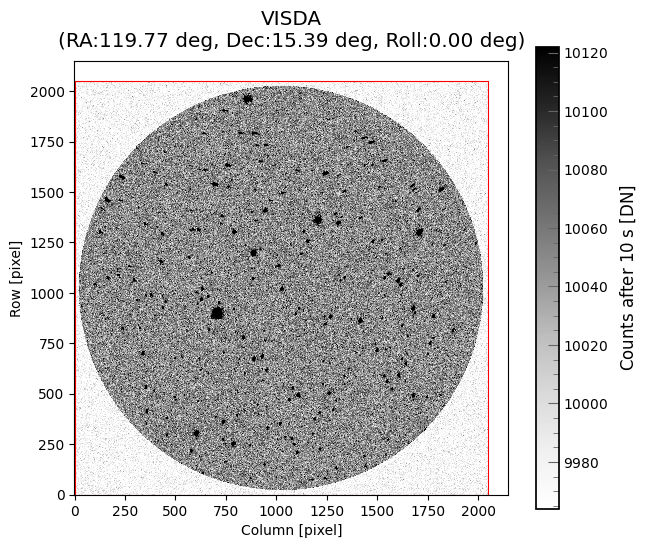

In [13]:
''' Plot the VIS Full Frame Image. '''
###  ROIs are in red boxes defining the subarrays, but we only take subarrays in part 2.
simVIS.show_FFI()

In [15]:
''' Create an Observation. '''
### This returns an astropy.io.fits.HDUList array. 
# `nreads` sets how many reads of the detector are coadded together to create a frame.
# `bin_frames` is a shortcut parameter to speed up computation. Must be a factor of nreads. We can ignore this for low nreads. 
# `nframes` sets how many frames will be returned.
# `start_time` indicates the time of observation. 
# `output_type` is set to array, for now. This make it easy to call, but we'll save it as a fits file later. 
###

### reduce the number of integrations to speed up calculations
reduction = 1 # set to 1 for no reduction
data = simVIS.observe(nreads=obs_dict[vis]['frames_per_int'], bin_frames=1, nframes=int(obs_dict[vis]['num_int']/reduction), start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|█████████████████| 17/17 [01:41<00:00,  5.99s/it]


(1, 15, 2048, 2048)

### NIR Observation

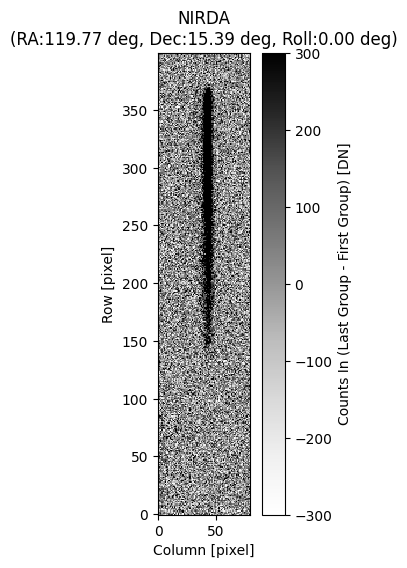

In [16]:
''' Plot the NIRDA subarray '''
simNIR.show_subarray();

In [17]:
''' Create a NIRDA observation. '''
### This returns an astropy.io.fits.HDUList array. The following parameters can be adjusted
# SC_Resets1 : Number of reset frames at the start of the first integration of exposure
# SC_Resets2 : Number of resent frames at the start of 1 through n integrations of exposure
# SC_DropFrames1 : Number of dropped frames after reset of any integration of exposure
# SC_DropFrames2 : Number of dropped frames in every group of integrations of exposure except the last group
# SC_DropFrames3 : Number of dropped frames in the last group of each integration of exposure
# SC_ReadFrames : Number of frames read during each group of integration of exposure
# SC_Groups : Number of groups per integration of exposure
# SC_Integrations : Number of integrations per exposure
# start_time : Time to start the observation. This is only used if returning a fits file, or supplying a flux function.
# noise : bool flag determining whether noise is simulated and included. Default is True.
# jitter : bool flag determining whether jitter is simulated and included. Default is True.
# output_type : String flag to determine the result output. Valid strings are "fits" or "array
###

ROIsize_override = (obs_dict[nir]['xpix'], obs_dict[nir]['ypix']) ### This cannot yet be specified in sim.observe(). For now, we have the default ROI size.

data = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time, output_type="array")

### The shape is: (num ROIs, num frames, nrows, ncolumns)
data.shape

Modeling Pixel Positions: 100%|███████████████████| 5/5 [00:10<00:00,  2.05s/it]


(2, 2, 400, 80)

## Save the Simulated Observation

In [18]:
''' Re-Create the observations in the correct format for the .fits file (i.e., output_type set to default) '''
### Before, object_type was array for easy computation in this notebook, but that is not correct for the .fits file
hdulist_vis = simVIS.observe(nreads=obs_dict[vis]['frames_per_int'], bin_frames=1, nframes=obs_dict[vis]['num_int'], start_time=start_time)
hdulist_nir = simNIR.observe(SC_ReadFrames=obs_dict[nir]['frames_per_int'], SC_Integrations=obs_dict[nir]['num_int'], start_time=start_time)


''' Save our simulated observation in a fits file '''
targ = target.replace(" ", "")
VISrois_outfile = "3.41_VISrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
NIRrois_outfile = "3.41_NIRrois_"+str(targ)+"_obs"+str(observation_number)+".fits"
hdulist_vis.writeto(VISrois_outfile, overwrite=True)
hdulist_nir.writeto(NIRrois_outfile, overwrite=True)

Modeling Pixel Positions: 100%|███████████████████| 1/1 [00:04<00:00,  4.52s/it]


In [19]:
### Show what is in our fits file: 
'''
Three FITS file extensions: 
    (1) PRIMARY: information about the simulated observation 
    (2) SCIENCE: data info, images
    (3) ROITABLE: VISDA pixel coordinates of the origin of the subarray, which is defined as the lower left corner
'''

hdul_rois = fits.open(VISrois_outfile) ### or NIRrois_outfile
print(hdul_rois.info())

#print('.')
#print('.')
#print('.')
#print('-- PRIMARY Headers --')
#print(hdul_rois[0].header)

#print('.')
#print('.')
#print('.')
#print('-- SCIENCE Headers --')
#print(hdul_rois[1].header)

#print('.')
#print('.')
#print('.')
#print('-- ROITABLE Headers --')
#print(hdul_rois[2].header)

Filename: 3.41_VISrois_GJ3470_obs0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  SCIENCE       1 ImageHDU        71   (2048, 2048, 15)   int64   
  2  ROITABLE      1 BinTableHDU     22   2R x 1C   [D]   
None


## Data Products

### RD-C2: This data will be used to develop a model of the Earthshine background.

## Generate SOC File

BEN'S NOTE: This is configured to make a single "template" file so that the scheduling code can choose the exact coordinates and timing on the fly for the FFI observations. The observing parameters should be correct and representative for a single FFI observation for this task.

In [30]:
'''Here we define the information required for scheduling the observation.'''
### Some variables may be removed/added/changed. Working on defining these with SOC meetings. 
### This is not all correct! Revisit and check once notebook and SOC .xml format are complete. 

variables = {
    'visit_id': '0341', ### setting based on task number. Could change. 
    'obs_id': f"{observation_number:03}", ### setting based on observation number. 
    'target': target, 
    'priority': 1, ### all commissioning is priority 1
    'start_time': start_time, 
    'stop_time': end_time, 
    'RA': ra0.value,
    'DEC': dec0.value, 
    'ffi_flag': 1,
    
    'NIR_AvgGroups': 1, ### check what this is
    'NIR_ROI_StartX': 1536, 
    'NIR_ROI_StartY': 1, 
    'NIR_ROI_SizeX': obs_dict[nir]['xpix'], 
    'NIR_ROI_SizeY': obs_dict[nir]['ypix'],
    'NIR_SC_Resets1': 1,
    'NIR_SC_Resets2': 1, 
    'NIR_SC_DropFrames1': 0,
    'NIR_SC_DropFrames2': 0,
    'NIR_SC_DropFrames3': 0, 
    'NIR_SC_ReadFrames': obs_dict[nir]['frames_per_int'],
    'NIR_targetID': target, 
    'NIR_SC_Groups': 1,
    'NIR_SC_Integrations': obs_dict[nir]['num_int'], 
    
    'VIS_StarRoiDetMethod': 1,  ### 0: monitor stars at positions defined in [PredefinedStarRoiRa, PredefinedStarRoiDec]. 1: Run star detection algorithm on first image and obtain star ROIs from results.
    'VIS_FramesPerCoadd': obs_dict[vis]['frames_per_int'], 
    'VIS_NumTotalFramesRequested': obs_dict[vis]['num_int'] * obs_dict[vis]['frames_per_int'], 
    'VIS_TargetRA': ra0.value, 
    'VIS_TargetDEC': dec0.value, 
    'VIS_IncludeFieldSolnsInResp': 1, ### Determines whether the Ra/Dec/Rot values calculated for each frame in the visible science collect will be included in the response message [1] or not [0].
    'VIS_StarRoiDimension': [obs_dict[vis]['xpix']], 
    'VIS_MaxNumStarRois': 9, ### max number of star ROIs that will be used for coadding signal from target stars if StarRoiDetMethod == 1.
    'VIS_numPredefinedStarRois': obs_dict[vis]['regions'], ### If StarRoiDetMethod==0, this is the number of [RA, DEC] coordinates contained in the PredefinedStarRoiRA and PredefinedStarRoiDEC vectors.
    'VIS_PredefinedStarRoiRa': '', ### currently defining as corner of ROI. We may update this to be ROI centers.
    'VIS_PredefinedStarRoiDec': '', 
    'VIS_targetID': target, 
    'VIS_NumExposuresMax': obs_dict[vis]['num_int'] * obs_dict[vis]['frames_per_int'], 
    'VIS_ExposureTime_us': frame_time_VIS * 1000000  
}

In [31]:
'''Generate the SOC .xml file'''

output_soc_file = variables['visit_id']+'_'+variables['obs_id']+'s_template_SOC.xml' 
generate_task_plan(variables, output_soc_file)
print('Generated XML file at ' + output_soc_file)

Generated XML file at 0341_000s_template_SOC.xml
